<a href="https://colab.research.google.com/github/VasilinaFrolova/-/blob/main/%D0%A0%D0%B0%D1%81%D1%87%D1%91%D1%82_U_%D1%82%D0%B5%D1%81%D1%82%D0%B0_%D0%BE%D0%B1%D1%89%D0%B8%D0%B5_%D0%B2%D0%BE%D0%BF%D1%80%D0%BE%D1%81%D1%8B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Установка библиотек
!pip install pandas scipy openpyxl -q

import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Загрузка файла
print("Пожалуйста, загрузите файл 'для рассчета U-теста.xlsx'")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

Пожалуйста, загрузите файл 'для рассчета U-теста.xlsx'


Saving для рассчета U-теста.xlsx to для рассчета U-теста.xlsx


In [ ]:
# Читаем лист 2
df = pd.read_excel(filename, sheet_name='Лист2')

In [ ]:
# Столбец с полом
df['Ваш пол'] = df['Ваш пол'].astype(str).str.strip()
мужчины = df[df['Ваш пол'] == 'Мужской']
женщины = df[df['Ваш пол'] == 'Женский']
print(f"Мужчин: {len(мужчины)}, Женщин: {len(женщины)}")

Мужчин: 41, Женщин: 63


In [ ]:
# Список столбцов для анализа (все они числовые, шкала 1-5)
вопросы = [
    'Как вы считаете, делает ли метафора (скрытое сравнение, образ), обобщение, контраст, юмор и т.п. рекламу более запоминающейся?',
    'Обращаете ли Вы внимание на цветовую гамму, шрифт, масштаб изображения в рекламе?',
    'Как Вы полагаете, Вы обращаете внимание на рекламу, когда интерес к товару, услуге уже был ранее?',
    'Как Вы полагаете, Вы обращаете внимание на рекламу, если она интересно оформлена (текст, изображение)?',
    'Считаете ли вы, что мужчины и женщины воспринимают рекламу по-разному?'
]

# Сокращённые названия для итоговой таблицы
short_names = [
    'Метафора запоминается',
    'Обращают внимание на цвет/шрифт',
    'Внимание при интересе',
    'Внимание при оформлении',
    'Воспринимают по-разному'
]

def calc_mannwhitney(col_name):
    m_data = мужчины[col_name].dropna().astype(float)
    w_data = женщины[col_name].dropna().astype(float)
    if len(m_data) < 5 or len(w_data) < 5:
        return (None, None, None, None, None, None)
    try:
        stat, p = mannwhitneyu(m_data, w_data, alternative='two-sided')
    except ValueError:
        return (None, None, None, None, None, None)
    mean_m = m_data.mean()
    mean_w = w_data.mean()
    median_m = m_data.median()
    median_w = w_data.median()
    return (stat, p, mean_m, mean_w, median_m, median_w)

results = []
for full_q, short_q in zip(вопросы, short_names):
    U, p, mean_m, mean_w, med_m, med_w = calc_mannwhitney(full_q)
    if U is None:
        continue
    significance = "Да" if p < 0.05 else "Нет"
    results.append({
        "Вопрос": short_q,
        "U-статистика": round(U, 2),
        "p-value": round(p, 5),
        "Среднее (муж)": round(mean_m, 2),
        "Среднее (жен)": round(mean_w, 2),
        "Медиана (муж)": round(med_m, 2),
        "Медиана (жен)": round(med_w, 2),
        "Значимость (p<0.05)": significance
    })

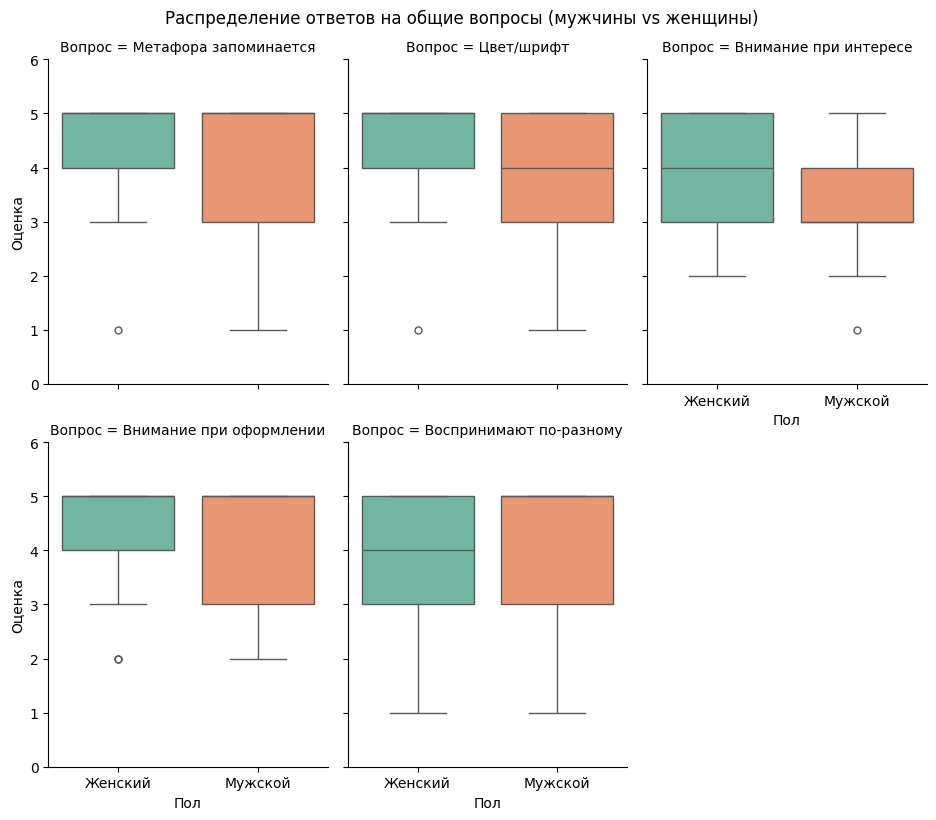

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Список исходных колонок и их коротких названий
questions = [
    'Как вы считаете, делает ли метафора (скрытое сравнение, образ), обобщение, контраст, юмор и т.п. рекламу более запоминающейся?',
    'Обращаете ли Вы внимание на цветовую гамму, шрифт, масштаб изображения в рекламе?',
    'Как Вы полагаете, Вы обращаете внимание на рекламу, когда интерес к товару, услуге уже был ранее?',
    'Как Вы полагаете, Вы обращаете внимание на рекламу, если она интересно оформлена (текст, изображение)?',
    'Считаете ли вы, что мужчины и женщины воспринимают рекламу по-разному?'
]
short_names = [
    'Метафора запоминается',
    'Цвет/шрифт',
    'Внимание при интересе',
    'Внимание при оформлении',
    'Воспринимают по-разному'
]

# Длинная таблица
rows = []
for q, short in zip(questions, short_names):
    vals = df[q].dropna().astype(float)
    gender_series = df.loc[vals.index, 'Ваш пол']
    for v, g in zip(vals, gender_series):
        rows.append([short, v, g])

long_df = pd.DataFrame(rows, columns=['Вопрос', 'Оценка', 'Пол'])

# График: по вертикали – оценка, по горизонтали – пол, facet – вопрос
g = sns.catplot(
    data=long_df,
    x='Пол',
    y='Оценка',
    col='Вопрос',
    kind='box',
    palette='Set2',
    height=4,
    aspect=0.8,
    col_wrap=3      # расположить в 3 колонки
)
g.fig.suptitle('Распределение ответов на общие вопросы (мужчины vs женщины)', y=1.02)
g.set(ylim=(0, 6))
g.savefig('boxplot_common_questions.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
result_df = pd.DataFrame(results)
print("\nРезультаты U-критерия Манна-Уитни для общих вопросов (Лист2):")
print(result_df.to_string(index=False))

output_filename = "mannwhitney_list2_results.xlsx"
result_df.to_excel(output_filename, index=False)
print(f"\nРезультаты сохранены в '{output_filename}'. Скачайте файл через панель слева.")